# Santander EDA v2

This notebook focuses on five small, modeling-oriented EDA modules:

1. `zero_count` / `nonzero_count` by `TARGET`
2. `TARGET` rate by `nonzero_count` activity bucket
3. `var38` peak value analysis
4. Single-feature AUC for new FE variables
5. EDA-to-modeling decision summary

The goal is to connect interpretable EDA findings directly to feature engineering decisions for the LightGBM FE experiment.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.metrics import roc_auc_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.5f}")

RNG_SEED = 42

# Suppress pandas fragmentation warnings caused by adding a few EDA columns interactively.
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)


In [2]:
# Load the cleaned training dataset used by the modeling notebooks.
train = pd.read_csv("train_clean.csv")

feature_cols = [c for c in train.columns if c not in ["ID", "TARGET"]]

print(f"Train shape: {train.shape}")
print(f"Number of modeling features before EDA FE: {len(feature_cols)}")
print(f"Overall dissatisfied rate: {train['TARGET'].mean():.5f}")


Train shape: (76020, 308)
Number of modeling features before EDA FE: 306
Overall dissatisfied rate: 0.03957


## 1. Sparsity / Activity Features by TARGET

This module checks whether dissatisfied customers (`TARGET=1`) have a different sparsity/activity profile from satisfied customers (`TARGET=0`).


In [3]:
# Create row-level sparsity/activity features.
train["zero_count"] = (train[feature_cols] == 0).sum(axis=1)
train["nonzero_count"] = (train[feature_cols] != 0).sum(axis=1)

sparsity_by_target = train.groupby("TARGET")[["zero_count", "nonzero_count"]].agg(["mean", "median", "std"])
sparsity_by_target


zero_count                    nonzero_count                  
             mean    median      std          mean   median      std
TARGET                                                              
0       272.40548 277.00000 17.20677      33.59452 29.00000 17.20677
1       278.96709 290.00000 19.40678      27.03291 16.00000 19.40678

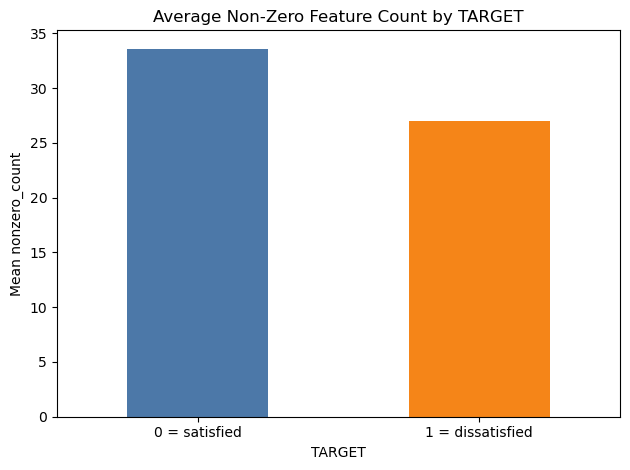

In [4]:
# Visualize average non-zero feature count by target class.
ax = train.groupby("TARGET")["nonzero_count"].mean().plot(kind="bar", color=["#4C78A8", "#F58518"])
ax.set_title("Average Non-Zero Feature Count by TARGET")
ax.set_xlabel("TARGET")
ax.set_ylabel("Mean nonzero_count")
ax.set_xticklabels(["0 = satisfied", "1 = dissatisfied"], rotation=0)
plt.tight_layout()
plt.show()


## 2. TARGET Rate by Activity Bucket

This module bins customers by `nonzero_count` quartiles and checks whether higher or lower activity groups have different dissatisfaction rates. This directly supports the heavy-user / active-customer modeling discussion.


In [5]:
# Bucket customers by activity level using nonzero_count quartiles.
train["activity_bucket"] = pd.qcut(
    train["nonzero_count"],
    q=4,
    labels=["Q1 lowest activity", "Q2", "Q3", "Q4 highest activity"],
    duplicates="drop",
)

activity_summary = train.groupby("activity_bucket", observed=False)["TARGET"].agg(
    total_customers="count",
    dissatisfied_customers="sum",
    dissatisfied_rate="mean",
)

activity_summary["lift_vs_overall"] = activity_summary["dissatisfied_rate"] / train["TARGET"].mean()
activity_summary


,total_customers,dissatisfied_customers,dissatisfied_rate,lift_vs_overall
activity_bucket,,,,
Q1 lowest activity,19080,1708,0.08952,2.26235
Q2,21076,324,0.01537,0.38851
Q3,17389,425,0.02444,0.61768
Q4 highest activity,18475,551,0.02982,0.75373


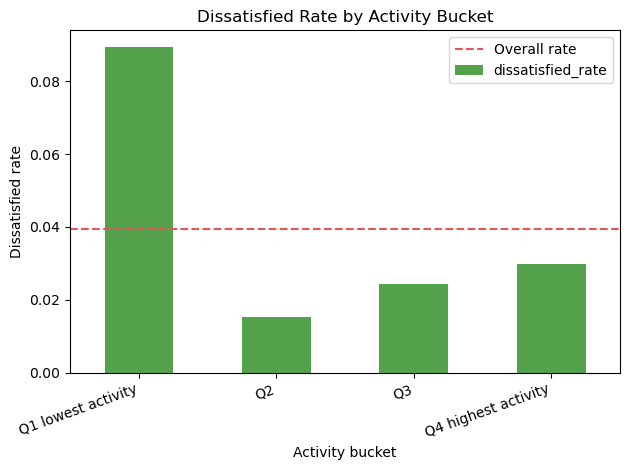

In [6]:
# Plot dissatisfaction rate by activity bucket against the overall baseline rate.
ax = activity_summary["dissatisfied_rate"].plot(kind="bar", color="#54A24B")
ax.axhline(train["TARGET"].mean(), color="#E45756", linestyle="--", label="Overall rate")
ax.set_title("Dissatisfied Rate by Activity Bucket")
ax.set_xlabel("Activity bucket")
ax.set_ylabel("Dissatisfied rate")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 3. `var38` Peak Value Analysis

The Santander third-place solution discussed special handling for `var38`. This module checks whether the known peak value forms a distinct customer group with a different dissatisfaction rate.


In [7]:
# Analyze the known var38 peak value as a possible special group.
peak = 117310.979016494

var38_summary = pd.DataFrame({
    "group": ["var38_peak", "var38_non_peak"],
    "count": [
        (train["var38"] == peak).sum(),
        (train["var38"] != peak).sum(),
    ],
    "target_1_count": [
        train.loc[train["var38"] == peak, "TARGET"].sum(),
        train.loc[train["var38"] != peak, "TARGET"].sum(),
    ],
    "target_rate": [
        train.loc[train["var38"] == peak, "TARGET"].mean(),
        train.loc[train["var38"] != peak, "TARGET"].mean(),
    ],
})

var38_summary["share_of_customers"] = var38_summary["count"] / len(train)
var38_summary["lift_vs_overall"] = var38_summary["target_rate"] / train["TARGET"].mean()
var38_summary


,group,count,target_1_count,target_rate,share_of_customers,lift_vs_overall
0,var38_peak,14868,614,0.04130,0.19558,1.04368
1,var38_non_peak,61152,2394,0.03915,0.80442,0.98938


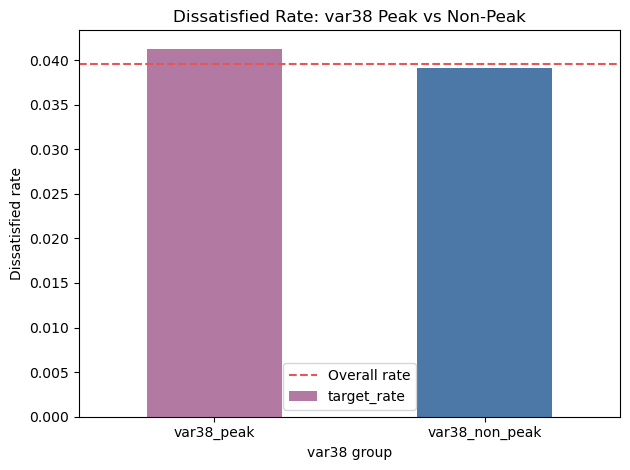

In [8]:
# Plot target rate for peak vs non-peak var38 groups.
ax = var38_summary.set_index("group")["target_rate"].plot(kind="bar", color=["#B279A2", "#4C78A8"])
ax.axhline(train["TARGET"].mean(), color="#E45756", linestyle="--", label="Overall rate")
ax.set_title("Dissatisfied Rate: var38 Peak vs Non-Peak")
ax.set_xlabel("var38 group")
ax.set_ylabel("Dissatisfied rate")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Single-Feature AUC for FE Variables

This module checks whether each newly engineered feature has standalone predictive signal. AUC is direction-adjusted using `max(AUC, 1 - AUC)`, so values above 0.50 indicate signal regardless of whether the relationship is positive or negative.


In [9]:
# Build var38 FE columns used in the LightGBM FE experiment.
train["var38_is_peak"] = (train["var38"] == peak).astype(int)
train["var38_log"] = np.log1p(train["var38"])
train.loc[train["var38"] == peak, "var38_log"] = 0

fe_cols = ["zero_count", "nonzero_count", "var38_is_peak", "var38_log"]

auc_rows = []
for col in fe_cols:
    if train[col].nunique() > 1:
        raw_auc = roc_auc_score(train["TARGET"], train[col])
        direction_adjusted_auc = max(raw_auc, 1 - raw_auc)
        auc_rows.append({
            "feature": col,
            "n_unique": train[col].nunique(),
            "raw_auc": raw_auc,
            "direction_adjusted_auc": direction_adjusted_auc,
        })

fe_auc = pd.DataFrame(auc_rows).sort_values("direction_adjusted_auc", ascending=False)
fe_auc


,feature,n_unique,raw_auc,direction_adjusted_auc
0,zero_count,120,0.63423,0.63423
1,nonzero_count,120,0.36577,0.63423
3,var38_log,57736,0.43041,0.56959
2,var38_is_peak,2,0.50445,0.50445


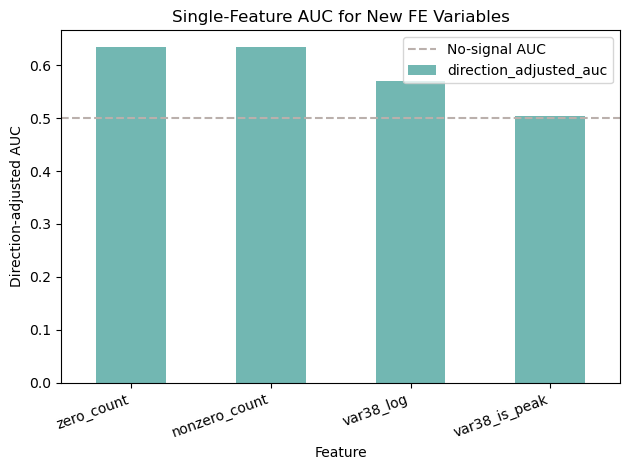

In [10]:
# Plot standalone AUC for the FE features.
ax = fe_auc.set_index("feature")["direction_adjusted_auc"].plot(kind="bar", color="#72B7B2")
ax.axhline(0.5, color="#BAB0AC", linestyle="--", label="No-signal AUC")
ax.set_title("Single-Feature AUC for New FE Variables")
ax.set_xlabel("Feature")
ax.set_ylabel("Direction-adjusted AUC")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 5. EDA-to-Modeling Decision Summary

This final table translates the EDA findings into modeling actions and experiment status.


In [11]:
# Summarize how EDA findings map to modeling decisions.
decision_summary = pd.DataFrame([
    {
        "EDA finding": "Many features are sparse; row activity differs by customer group",
        "Modeling decision": "Added zero_count / nonzero_count",
        "Result": "Tested in LightGBM FE; OOF AUC improved from 0.83749 to 0.83825; Public/Private changed",
    },
    {
        "EDA finding": "var38 has a known peak value that behaves like a special group",
        "Modeling decision": "Added var38_is_peak / var38_log",
        "Result": "Tested in LightGBM FE",
    },
    {
        "EDA finding": "TARGET is highly imbalanced, with overall dissatisfied rate near 3.96%",
        "Modeling decision": "Next: test scale_pos_weight or class_weight",
        "Result": "Pending",
    },
])

decision_summary


,EDA finding,Modeling decision,Result
0,Many features are sparse; row activity differs...,Added zero_count / nonzero_count,Tested in LightGBM FE; OOF AUC improved from 0...
1,var38 has a known peak value that behaves like...,Added var38_is_peak / var38_log,Tested in LightGBM FE
2,"TARGET is highly imbalanced, with overall diss...",Next: test scale_pos_weight or class_weight,Pending


In [12]:
# Print a compact narrative summary for slides or the README.
overall_rate = train["TARGET"].mean()
target_activity = train.groupby("TARGET")["nonzero_count"].mean()
lowest_bucket_rate = activity_summary["dissatisfied_rate"].iloc[0]
highest_bucket_rate = activity_summary["dissatisfied_rate"].iloc[-1]
peak_rate = var38_summary.loc[var38_summary["group"] == "var38_peak", "target_rate"].iloc[0]
non_peak_rate = var38_summary.loc[var38_summary["group"] == "var38_non_peak", "target_rate"].iloc[0]
best_fe_feature = fe_auc.iloc[0]

print("EDA v2 key findings:")
print(f"1. Mean nonzero_count: TARGET=0 -> {target_activity.loc[0]:.2f}, TARGET=1 -> {target_activity.loc[1]:.2f}.")
print(f"2. Overall dissatisfied rate: {overall_rate:.5f}; lowest activity bucket: {lowest_bucket_rate:.5f}; highest activity bucket: {highest_bucket_rate:.5f}.")
print(f"3. var38 peak target rate: {peak_rate:.5f}; non-peak target rate: {non_peak_rate:.5f}.")
print(f"4. Strongest standalone FE feature: {best_fe_feature['feature']} with adjusted AUC {best_fe_feature['direction_adjusted_auc']:.5f}.")


EDA v2 key findings:
1. Mean nonzero_count: TARGET=0 -> 33.59, TARGET=1 -> 27.03.
2. Overall dissatisfied rate: 0.03957; lowest activity bucket: 0.08952; highest activity bucket: 0.02982.
3. var38 peak target rate: 0.04130; non-peak target rate: 0.03915.
4. Strongest standalone FE feature: zero_count with adjusted AUC 0.63423.
